In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import geopandas as gpd

In [ ]:
#Full dataset with storm events from 2015-2025
counties = pd.read_csv("illinois_counties.csv")
year2025 = pd.read_csv("data/StormEvents_details-ftp_v1.0_d2025_c20250818.csv")
year2024 = pd.read_csv("data/StormEvents_details-ftp_v1.0_d2024_c20250818.csv")
year2023 = pd.read_csv("data/StormEvents_details-ftp_v1.0_d2023_c20250731.csv")
year2022 = pd.read_csv("data/StormEvents_details-ftp_v1.0_d2022_c20250721.csv")
year2021 = pd.read_csv("data/StormEvents_details-ftp_v1.0_d2021_c20250520.csv")
year2020 = pd.read_csv("data/StormEvents_details-ftp_v1.0_d2020_c20250702.csv")
year2019 = pd.read_csv("data/StormEvents_details-ftp_v1.0_d2019_c20250520.csv")
year2018 = pd.read_csv("data/StormEvents_details-ftp_v1.0_d2018_c20250520.csv")
year2017 = pd.read_csv("data/StormEvents_details-ftp_v1.0_d2017_c20250520.csv")
year2016 = pd.read_csv("data/StormEvents_details-ftp_v1.0_d2016_c20250818.csv")
year2015 = pd.read_csv("data/StormEvents_details-ftp_v1.0_d2015_c20250818.csv")



In [ ]:
storm_full = pd.concat([year2015, year2016, year2017, year2018, year2019, year2020, year2021, year2022, year2023, year2024, year2025], ignore_index=True)
#Clean data so county names match 
counties['county'] = (
    counties['county']
    .str.replace('-', ' ', regex=False)                      
    .str.replace("dekalb", "DE KALB", case=False, regex=False)
    .str.replace("dupage", "DU PAGE", case=False, regex=False)
    .str.replace("lasalle", "LA SALLE", case=False, regex=False)
    .str.upper()
    .str.replace('st clair', 'ST. CLAIR', case=False, regex=False)                              
)
#Select incident range
illinois = storm_full[storm_full["STATE"] == "ILLINOIS"]
illinois2 = illinois[(illinois["BEGIN_YEARMONTH"] >= 201510) &
                     (illinois["BEGIN_YEARMONTH"] <= 202510)]
#convert property and crop damage to floats
def convert_damage(value):
    if isinstance(value, str):
        value = value.upper().replace(',', '').strip()
        if value.endswith('K'):
            return int(float(value[:-1]) * 1000)
        elif value.endswith('M'):
            return int(float(value[:-1]) * 1_000_000)
        elif value.endswith('B'):
            return int(float(value[:-1]) * 1_000_000_000)
        else:
            return int(float(value))
    return value  

In [ ]:
illinois_map = gpd.read_file("IL_BNDY_County_Py[1].shp")

In [ ]:
illinois2['DAMAGE_PROPERTY'] = illinois2['DAMAGE_PROPERTY'].apply(convert_damage)
illinois2['DAMAGE_CROPS'] = illinois2['DAMAGE_CROPS'].apply(convert_damage)
#Combine incidents with corresponding county data
merged = pd.merge(
    illinois2,
    counties,
    left_on='CZ_NAME',
    right_on='county',
    how='inner'  # or 'left' if you want to keep all storm events
)
#clean
merged_filled = merged.fillna(0)
#plot amount of incidents with property damage
damaging_incidents = merged_filled[merged_filled['DAMAGE_PROPERTY'] > 0]
incident_counts = damaging_incidents['county'].value_counts().sort_values(ascending=False)

C:\Users\maxwe\AppData\Local\Temp\ipykernel_19216\1684160503.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  illinois2['DAMAGE_PROPERTY'] = illinois2['DAMAGE_PROPERTY'].apply(convert_damage)
C:\Users\maxwe\AppData\Local\Temp\ipykernel_19216\1684160503.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  illinois2['DAMAGE_CROPS'] = illinois2['DAMAGE_CROPS'].apply(convert_damage)


In [ ]:
merged["CZ_NAME"].unique()

Index(['BEGIN_YEARMONTH', 'BEGIN_DAY', 'BEGIN_TIME', 'END_YEARMONTH',
       'END_DAY', 'END_TIME', 'EPISODE_ID', 'EVENT_ID', 'STATE', 'STATE_FIPS',
       'YEAR', 'MONTH_NAME', 'EVENT_TYPE', 'CZ_TYPE', 'CZ_FIPS', 'CZ_NAME',
       'WFO', 'BEGIN_DATE_TIME', 'CZ_TIMEZONE', 'END_DATE_TIME',
       'INJURIES_DIRECT', 'INJURIES_INDIRECT', 'DEATHS_DIRECT',
       'DEATHS_INDIRECT', 'DAMAGE_PROPERTY', 'DAMAGE_CROPS', 'SOURCE',
       'MAGNITUDE', 'MAGNITUDE_TYPE', 'FLOOD_CAUSE', 'CATEGORY', 'TOR_F_SCALE',
       'TOR_LENGTH', 'TOR_WIDTH', 'TOR_OTHER_WFO', 'TOR_OTHER_CZ_STATE',
       'TOR_OTHER_CZ_FIPS', 'TOR_OTHER_CZ_NAME', 'BEGIN_RANGE',
       'BEGIN_AZIMUTH', 'BEGIN_LOCATION', 'END_RANGE', 'END_AZIMUTH',
       'END_LOCATION', 'BEGIN_LAT', 'BEGIN_LON', 'END_LAT', 'END_LON',
       'EPISODE_NARRATIVE', 'EVENT_NARRATIVE', 'DATA_SOURCE', 'county', 'fips',
       'population', 'sqr_miles', 'median_age', 'per_capita_income',
       'median_household_income', 'percent_below_poverty_line',
    

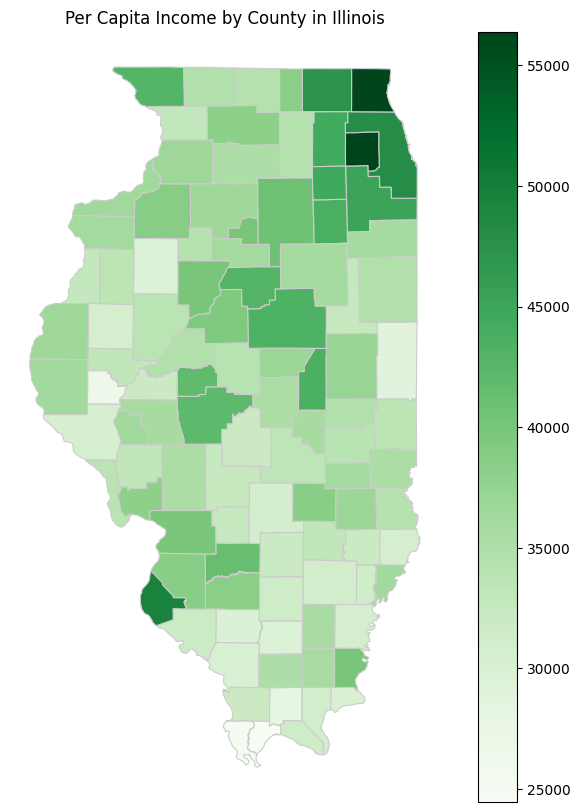

In [ ]:
illinois_map['county'] = (
    illinois_map['COUNTY_NAM']
    .str.replace('-', ' ', regex=False)
    .str.replace("LASALLE", "LA SALLE", regex=False)
    .str.replace("DEKALB", "DE KALB", regex=False)
    .str.replace("DEWITT", "DE WITT", regex=False)
    .str.replace("DUPAGE", "DU PAGE", regex=False)
    .str.strip()
    .str.upper()
)
map_data = illinois_map.merge(
    counties[['county', 'per_capita_income']],
    on='county',
    how='left'
)
map_data['per_capita_income'] = map_data['per_capita_income'].fillna(0)
fig, ax = plt.subplots(1, 1, figsize=(10, 10))
map_data.plot(
    column='per_capita_income',
    cmap='Greens',
    linewidth=0.8,
    ax=ax,
    edgecolor='0.8',
    legend=True
)

plt.title('Per Capita Income by County in Illinois')
plt.axis('off')
plt.show()

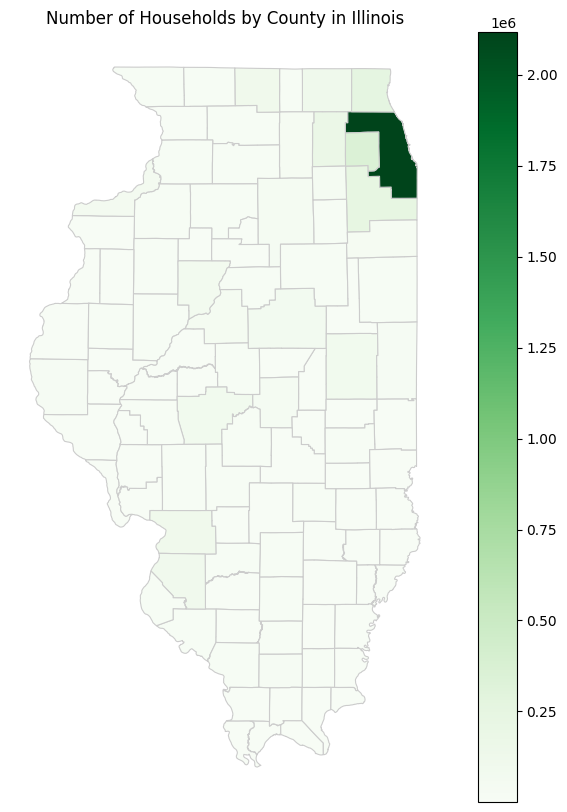

In [ ]:
illinois_map['county'] = (
    illinois_map['COUNTY_NAM']
    .str.replace('-', ' ', regex=False)
    .str.replace("LASALLE", "LA SALLE", regex=False)
    .str.replace("DEKALB", "DE KALB", regex=False)
    .str.replace("DEWITT", "DE WITT", regex=False)
    .str.replace("DUPAGE", "DU PAGE", regex=False)

    .str.strip()
    .str.upper()
)
map_data = illinois_map.merge(
    counties[['county', 'number_of_households']],
    on='county',
    how='left'
)
map_data['number_of_households'] = map_data['number_of_households'].fillna(0)
fig, ax = plt.subplots(1, 1, figsize=(10, 10))
map_data.plot(
    column='number_of_households',
    cmap='Greens',
    linewidth=0.8,
    ax=ax,
    edgecolor='0.8',
    legend=True
)

plt.title('Number of Households by County in Illinois')
plt.axis('off')
plt.show()

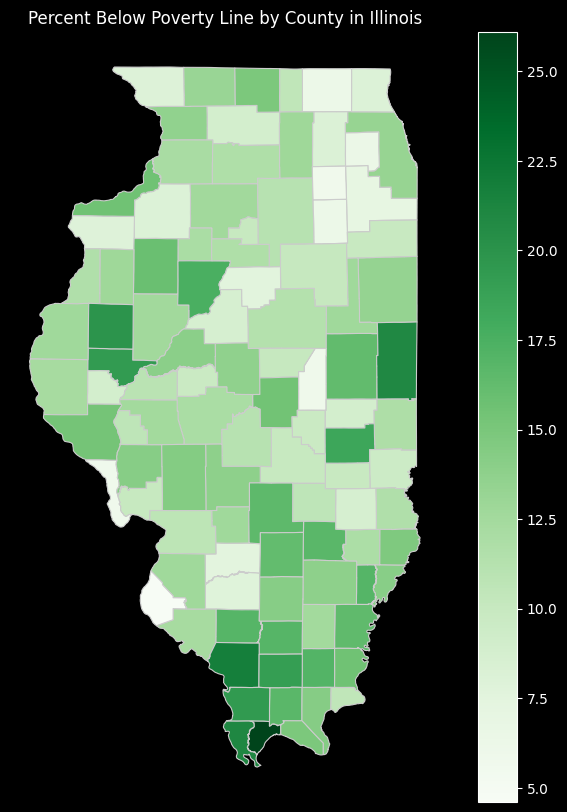

In [ ]:
plt.style.use('dark_background')
illinois_map['county'] = (
    illinois_map['COUNTY_NAM']
    .str.replace('-', ' ', regex=False)
    .str.replace("LASALLE", "LA SALLE", regex=False)
    .str.replace("DEKALB", "DE KALB", regex=False)
    .str.replace("DEWITT", "DE WITT", regex=False)
    .str.replace("DUPAGE", "DU PAGE", regex=False)
    .str.strip()
    .str.upper()
)
map_data = illinois_map.merge(
    counties[['county', 'percent_below_poverty_line']],
    on='county',
    how='left'
)
map_data['percent_below_poverty_line'] = map_data['percent_below_poverty_line'].fillna(0)
fig, ax = plt.subplots(1, 1, figsize=(10, 10))
map_data.plot(
    column='percent_below_poverty_line',
    cmap='Greens',
    linewidth=0.8,
    ax=ax,
    edgecolor='0.8',
    legend=True
)

plt.title('Percent Below Poverty Line by County in Illinois')
plt.axis('off')
plt.show()

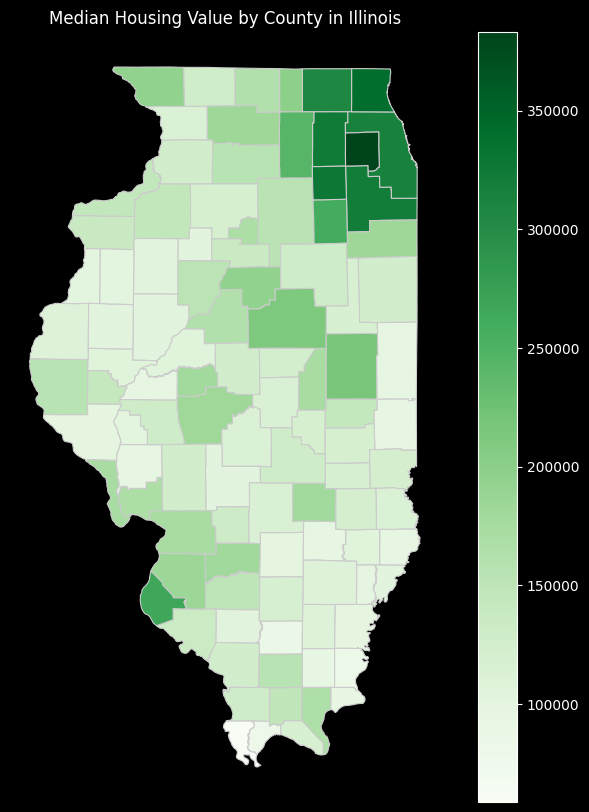

In [ ]:
plt.style.use('dark_background')
illinois_map['county'] = (
    illinois_map['COUNTY_NAM']
    .str.replace('-', ' ', regex=False)
    .str.replace("LASALLE", "LA SALLE", regex=False)
    .str.replace("DEKALB", "DE KALB", regex=False)
    .str.replace("DEWITT", "DE WITT", regex=False)
    .str.replace("DUPAGE", "DU PAGE", regex=False)
    .str.strip()
    .str.upper()
)
map_data = illinois_map.merge(
    counties[['county', 'median_housing_value']],
    on='county',
    how='left'
)
map_data['median_housing_value'] = map_data['median_housing_value'].fillna(0)
fig, ax = plt.subplots(1, 1, figsize=(10, 10))
map_data.plot(
    column='median_housing_value',
    cmap='Greens',
    linewidth=0.8,
    ax=ax,
    edgecolor='0.8',
    legend=True
)

plt.title('Median Housing Value by County in Illinois')
plt.axis('off')
plt.show()

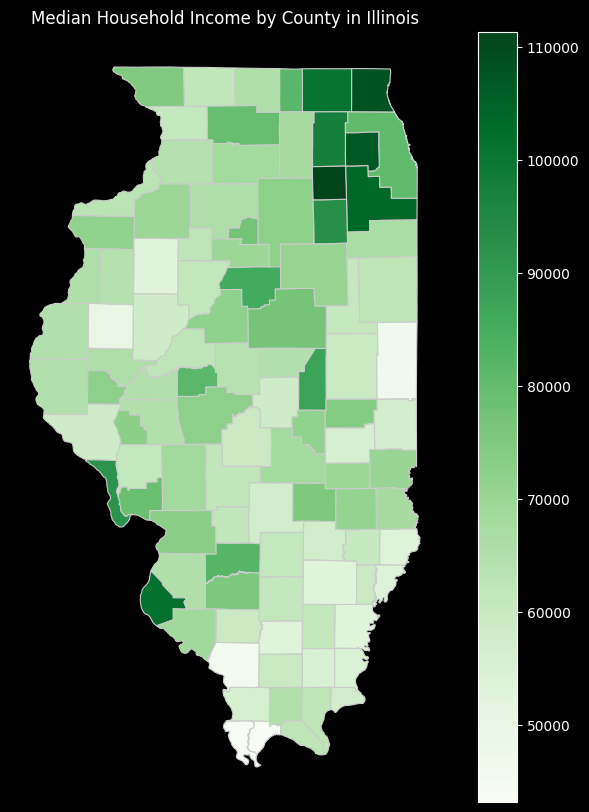

In [ ]:
illinois_map['county'] = (
    illinois_map['COUNTY_NAM']
    .str.replace('-', ' ', regex=False)
    .str.replace("LASALLE", "LA SALLE", regex=False)
    .str.replace("DEKALB", "DE KALB", regex=False)
    .str.replace("DEWITT", "DE WITT", regex=False)
    .str.replace("DUPAGE", "DU PAGE", regex=False)
    .str.strip()
    .str.upper()
)
map_data = illinois_map.merge(
    counties[['county', 'median_household_income']],
    on='county',
    how='left'
)
map_data['median_household_income'] = map_data['median_household_income'].fillna(0)
fig, ax = plt.subplots(1, 1, figsize=(10, 10))
map_data.plot(
    column='median_household_income',
    cmap='Greens',
    linewidth=0.8,
    ax=ax,
    edgecolor='0.8',
    legend=True
)

plt.title('Median Household Income by County in Illinois')
plt.axis('off')
plt.show()

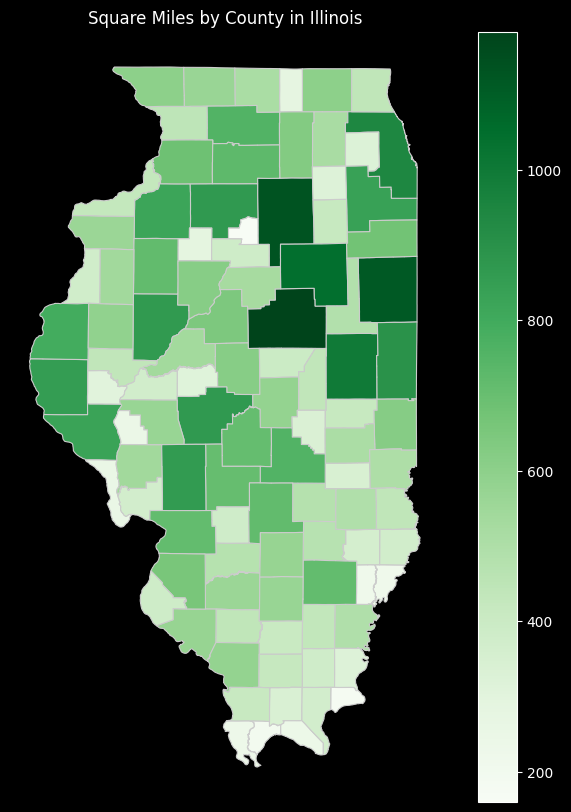

In [ ]:
illinois_map['county'] = (
    illinois_map['COUNTY_NAM']
    .str.replace('-', ' ', regex=False)
    .str.replace("LASALLE", "LA SALLE", regex=False)
    .str.replace("DEKALB", "DE KALB", regex=False)
    .str.replace("DEWITT", "DE WITT", regex=False)
    .str.replace("DUPAGE", "DU PAGE", regex=False)
    .str.strip()
    .str.upper()
)
map_data = illinois_map.merge(
    counties[['county', 'sqr_miles']],
    on='county',
    how='left'
)
map_data['sqr_miles'] = map_data['sqr_miles'].fillna(0)
fig, ax = plt.subplots(1, 1, figsize=(10, 10))
map_data.plot(
    column='sqr_miles',
    cmap='Greens',
    linewidth=0.8,
    ax=ax,
    edgecolor='0.8',
    legend=True
)

plt.title('Square Miles by County in Illinois')
plt.axis('off')
plt.show()
 

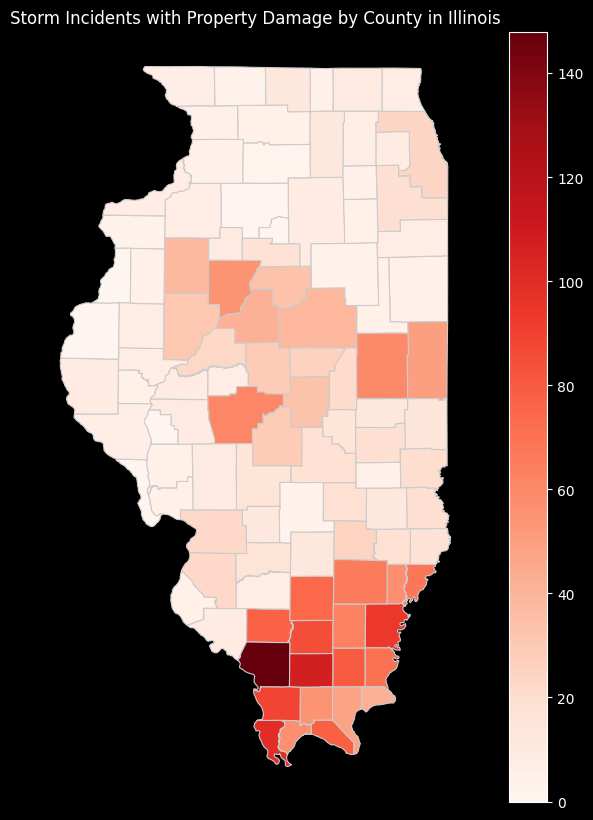

In [ ]:
plt.style.use('dark_background')
# Count incidents with property damage > 0
incident_counts = (
    merged_filled[merged_filled['DAMAGE_PROPERTY'] > 0]
    .groupby('county')
    .size()
    .reset_index(name='incident_count')
)
# Clean county names to match the shapefile
incident_counts['county'] = (
    incident_counts['county']
    .str.replace('-', ' ', regex=False)
    .str.replace('.', '', regex=False)
    .str.strip()
    .str.upper()
)
illinois_map['county'] = (
    illinois_map['COUNTY_NAM']
    .str.replace('-', ' ', regex=False)
    .str.replace("LASALLE", "LA SALLE", regex=False)
    .str.replace("DEKALB", "DE KALB", regex=False)
    .str.replace("DEWITT", "DE WITT", regex=False)
    .str.replace("DUPAGE", "DU PAGE", regex=False)
    .str.replace("ST. CLAIR", "ST ClAIR", regex=False)
    .str.strip()
    .str.upper()
)
map_data = illinois_map.merge(incident_counts, on='county', how='left')
map_data['incident_count'] = map_data['incident_count'].fillna(0)
fig, ax = plt.subplots(1, 1, figsize=(10, 10))
map_data.plot(
    column='incident_count',
    cmap='Reds',
    linewidth=0.8,
    ax=ax,
    edgecolor='0.8',
    legend=True
)

plt.title('Storm Incidents with Property Damage by County in Illinois')
plt.axis('off')
plt.show()

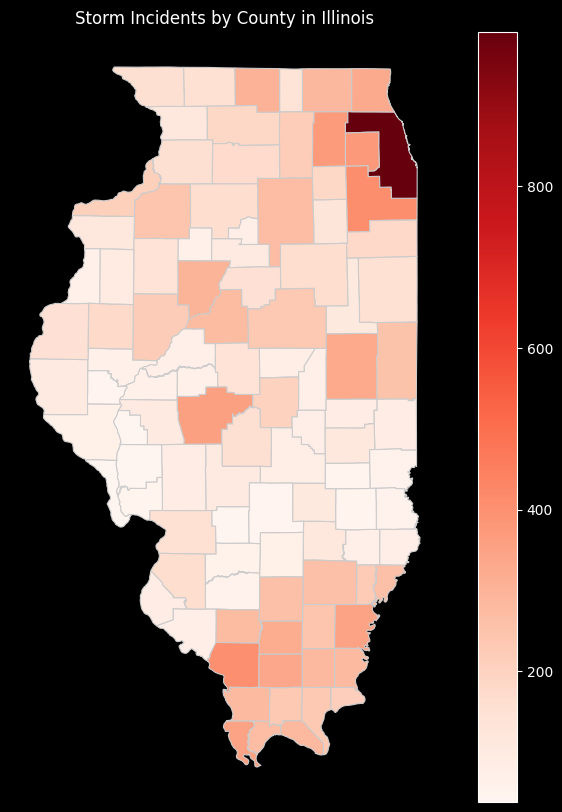

In [ ]:
plt.style.use('dark_background')
incident_counts = (
    merged_filled
    .groupby('county')
    .size()
    .reset_index(name='incident_count')
)
# Clean county names to match the shapefile
incident_counts['county'] = (
    incident_counts['county']
    .str.replace('-', ' ', regex=False)
    .str.replace('.', '', regex=False)
    .str.strip()
    .str.upper()
)
illinois_map['county'] = (
    illinois_map['COUNTY_NAM']
    .str.replace('-', ' ', regex=False)
    .str.replace("LASALLE", "LA SALLE", regex=False)
    .str.replace("DEKALB", "DE KALB", regex=False)
    .str.replace("DEWITT", "DE WITT", regex=False)
    .str.replace("DUPAGE", "DU PAGE", regex=False)
    .str.replace("ST. CLAIR", "ST ClAIR", regex=False)
    .str.strip()
    .str.upper()
)
map_data = illinois_map.merge(incident_counts, on='county', how='left')
map_data['incident_count'] = map_data['incident_count'].fillna(0)
fig, ax = plt.subplots(1, 1, figsize=(10, 10))
map_data.plot(
    column='incident_count',
    cmap='Reds',
    linewidth=0.8,
    ax=ax,
    edgecolor='0.8',
    legend=True
)

plt.title('Storm Incidents by County in Illinois')
plt.axis('off')
plt.show()

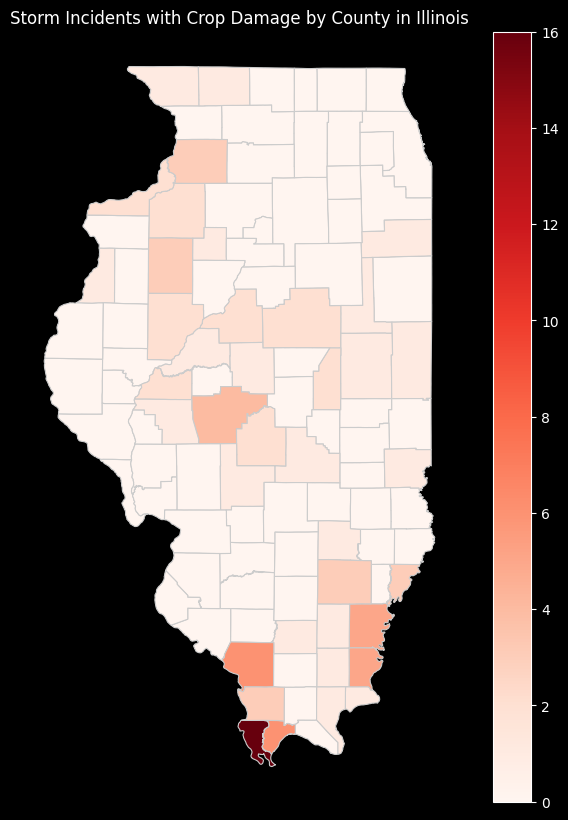

In [ ]:
# Count incidents with crop damage > 0
incident_counts = (
    merged_filled[merged_filled['DAMAGE_CROPS'] > 0]
    .groupby('county')
    .size()
    .reset_index(name='incident_count')
)
# Clean county names to match the shapefile
incident_counts['county'] = (
    incident_counts['county']
    .str.replace('-', ' ', regex=False)
    .str.replace('.', '', regex=False)
    .str.strip()
    .str.upper()
)
illinois_map['county'] = (
    illinois_map['COUNTY_NAM']
    .str.replace('-', ' ', regex=False)
    .str.replace("LASALLE", "LA SALLE", regex=False)
    .str.replace("DEKALB", "DE KALB", regex=False)
    .str.replace("DEWITT", "DE WITT", regex=False)
    .str.replace("DUPAGE", "DU PAGE", regex=False)
    .str.strip()
    .str.upper()
)
map_data = illinois_map.merge(incident_counts, on='county', how='left')
map_data['incident_count'] = map_data['incident_count'].fillna(0)
fig, ax = plt.subplots(1, 1, figsize=(10, 10))
map_data.plot(
    column='incident_count',
    cmap='Reds',
    linewidth=0.8,
    ax=ax,
    edgecolor='0.8',
    legend=True
)

plt.title('Storm Incidents with Crop Damage by County in Illinois')
plt.axis('off')
plt.show()

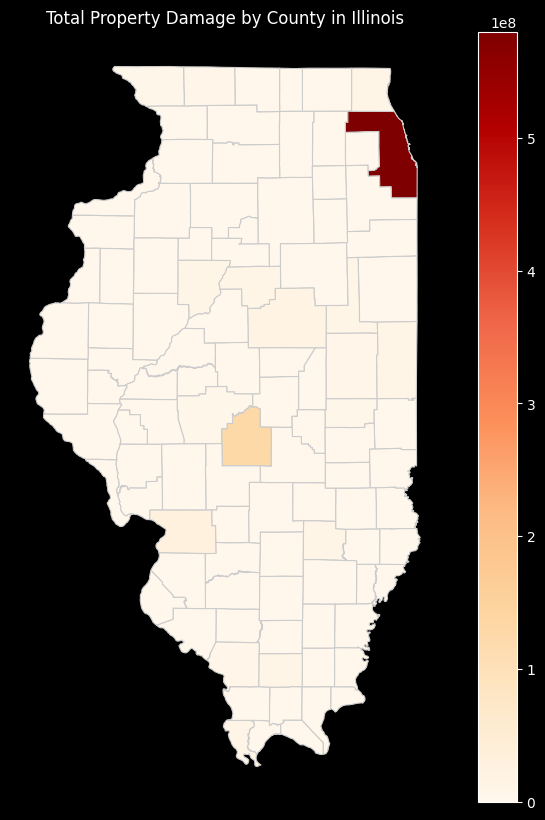

In [ ]:
damage_totals = (
    merged_filled[merged_filled['DAMAGE_PROPERTY'] > 0]
    .groupby('county')['DAMAGE_PROPERTY']
    .sum()
    .reset_index(name='total_damage')
)
damage_totals['county'] = (
    damage_totals['county']
    .str.replace('-', ' ', regex=False)
    .str.replace('.', '', regex=False)
    .str.strip()
    .str.upper()
)

illinois_map['county'] = (
    illinois_map['COUNTY_NAM']
    .str.replace('-', ' ', regex=False)
    .str.replace("LASALLE", "LA SALLE", regex=False)
    .str.replace("DEKALB", "DE KALB", regex=False)
    .str.replace("DEWITT", "DE WITT", regex=False)
    .str.replace("DUPAGE", "DU PAGE", regex=False)
    .str.strip()
    .str.upper()
)
map_data = illinois_map.merge(damage_totals, on='county', how='left')
map_data['total_damage'] = map_data['total_damage'].fillna(0)
fig, ax = plt.subplots(1, 1, figsize=(10, 10))
map_data.plot(
    column='total_damage',
    cmap='OrRd',
    linewidth=0.8,
    ax=ax,
    edgecolor='0.8',
    legend=True
)

plt.title('Total Property Damage by County in Illinois')
plt.axis('off')
plt.show()

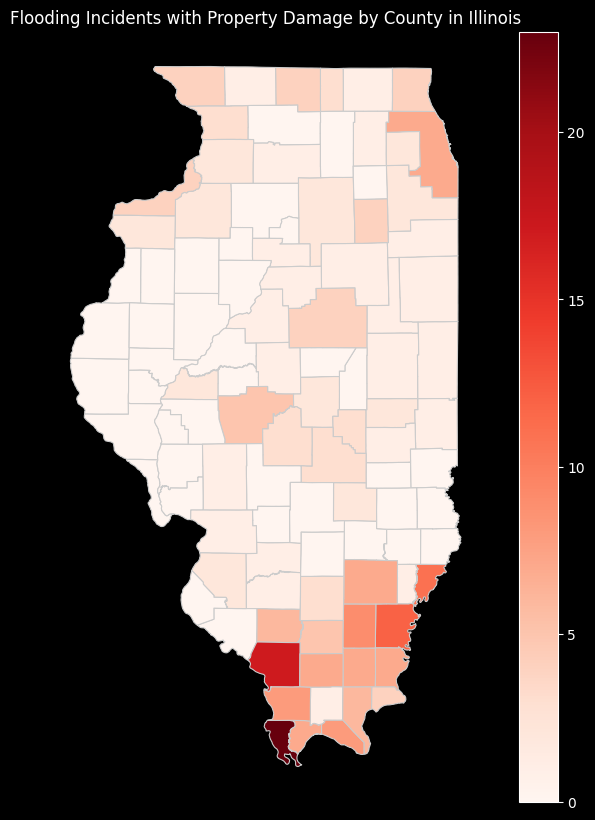

In [ ]:
# Count incidents with property damage > 0
incident_counts = (
    merged_filled[
        (merged_filled['DAMAGE_PROPERTY'] > 0) &
        (
            (merged_filled["EVENT_TYPE"] == "Flood") |
            (merged_filled["EVENT_TYPE"] == "Flash Flood") |
            (merged_filled["EVENT_TYPE"] == "Lakeshore Flood")
        )
    ]
    .groupby('county')
    .size()
    .reset_index(name="incident_count")
)
# Clean county names to match the shapefile
incident_counts['county'] = (
    incident_counts['county']
    .str.replace('-', ' ', regex=False)
    .str.replace('.', '', regex=False)
    .str.strip()
    .str.upper()
)
illinois_map['county'] = (
    illinois_map['COUNTY_NAM']
    .str.replace('-', ' ', regex=False)
    .str.replace("LASALLE", "LA SALLE", regex=False)
    .str.replace("DEKALB", "DE KALB", regex=False)
    .str.replace("DEWITT", "DE WITT", regex=False)
    .str.replace("DUPAGE", "DU PAGE", regex=False)
    .str.replace("ST. CLAIR", "ST ClAIR", regex=False)
    .str.strip()
    .str.upper()
)
map_data = illinois_map.merge(incident_counts, on='county', how='left')
map_data['incident_count'] = map_data['incident_count'].fillna(0)
fig, ax = plt.subplots(1, 1, figsize=(10, 10))
map_data.plot(
    column='incident_count',
    cmap='Reds',
    linewidth=0.8,
    ax=ax,
    edgecolor='0.8',
    legend=True
)

plt.title('Flooding Incidents with Property Damage by County in Illinois')
plt.axis('off')
plt.show()

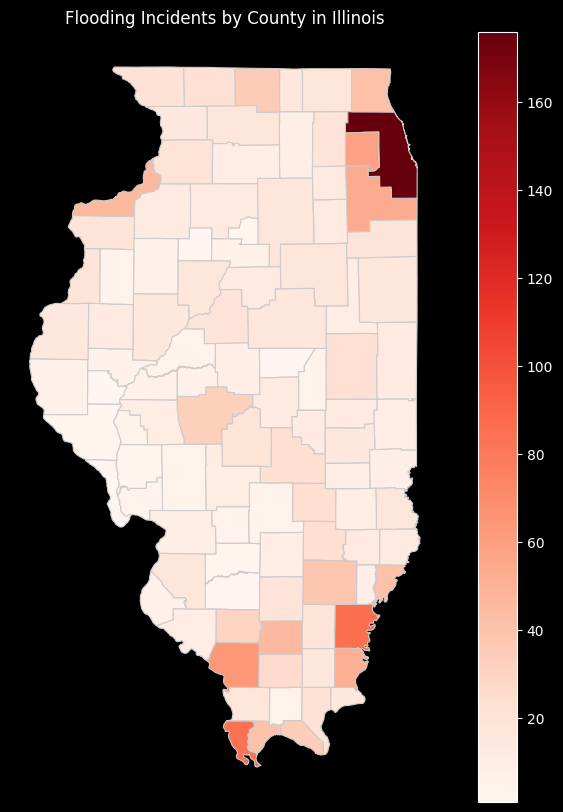

In [ ]:
incident_counts = (
    merged_filled[
        (
            (merged_filled["EVENT_TYPE"] == "Flood") |
            (merged_filled["EVENT_TYPE"] == "Flash Flood") |
            (merged_filled["EVENT_TYPE"] == "Lakeshore Flood")
        )
    ]
    .groupby('county')
    .size()
    .reset_index(name="incident_count")
)
# Clean county names to match the shapefile
incident_counts['county'] = (
    incident_counts['county']
    .str.replace('-', ' ', regex=False)
    .str.replace('.', '', regex=False)
    .str.strip()
    .str.upper()
)
illinois_map['county'] = (
    illinois_map['COUNTY_NAM']
    .str.replace('-', ' ', regex=False)
    .str.replace("LASALLE", "LA SALLE", regex=False)
    .str.replace("DEKALB", "DE KALB", regex=False)
    .str.replace("DEWITT", "DE WITT", regex=False)
    .str.replace("DUPAGE", "DU PAGE", regex=False)
    .str.replace("ST. CLAIR", "ST ClAIR", regex=False)
    .str.strip()
    .str.upper()
)
map_data = illinois_map.merge(incident_counts, on='county', how='left')
map_data['incident_count'] = map_data['incident_count'].fillna(0)
fig, ax = plt.subplots(1, 1, figsize=(10, 10))
map_data.plot(
    column='incident_count',
    cmap='Reds',
    linewidth=0.8,
    ax=ax,
    edgecolor='0.8',
    legend=True
)

plt.title('Flooding Incidents by County in Illinois')
plt.axis('off')
plt.show()

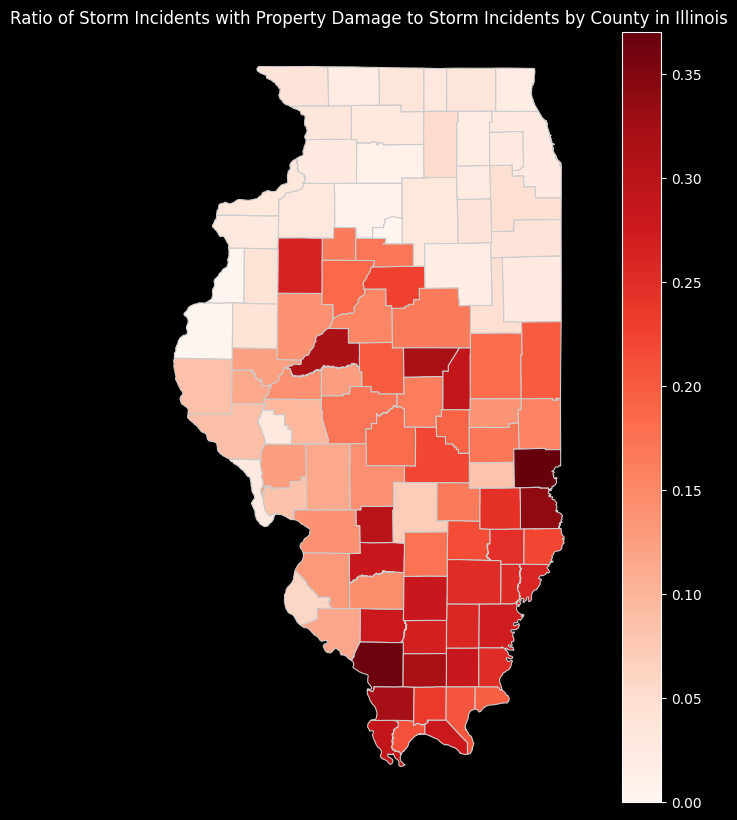

In [ ]:
plt.style.use('dark_background')

# Count incidents with property damage > 0
damage_counts = (
    merged_filled[merged_filled['DAMAGE_PROPERTY'] > 0]
    .groupby('county')
    .size()
    .reset_index(name='damage_count')
)
# Clean county names to match the shapefile
damage_counts['county'] = (
    damage_counts['county']
    .str.replace('-', ' ', regex=False)
    .str.replace('.', '', regex=False)
    .str.strip()
    .str.upper()
)

incident_counts = (
    merged_filled
    .groupby('county')
    .size()
    .reset_index(name='incident_count')
)
# Clean county names to match the shapefile
incident_counts['county'] = (
    incident_counts['county']
    .str.replace('-', ' ', regex=False)
    .str.replace('.', '', regex=False)
    .str.strip()
    .str.upper()
)

illinois_map['county'] = (
    illinois_map['COUNTY_NAM']
    .str.replace('-', ' ', regex=False)
    .str.replace("LASALLE", "LA SALLE", regex=False)
    .str.replace("DEKALB", "DE KALB", regex=False)
    .str.replace("DEWITT", "DE WITT", regex=False)
    .str.replace("DUPAGE", "DU PAGE", regex=False)
    .str.replace("ST. CLAIR", "ST ClAIR", regex=False)
    .str.strip()
    .str.upper()
)
map_data = illinois_map.merge(damage_counts, on='county', how='left')
map_data = map_data.merge(incident_counts, on='county', how='left')
map_data['damage_count'] = map_data['damage_count'].fillna(0)
map_data['incident_count'] = map_data['incident_count'].fillna(0)
map_data['damage_ratio'] = map_data.apply(
    lambda row: row['damage_count'] / row['incident_count'] if row['incident_count'] > 0 else 0,
    axis=1
)
fig, ax = plt.subplots(1, 1, figsize=(10, 10))
map_data.plot(
    column='damage_ratio',
    cmap='Reds',
    linewidth=0.8,
    ax=ax,
    edgecolor='0.8',
    legend=True
)

plt.title('Ratio of Storm Incidents with Property Damage to Storm Incidents by County in Illinois')
plt.axis('off')
plt.show()
pd.set_option('display.max_rows', None)


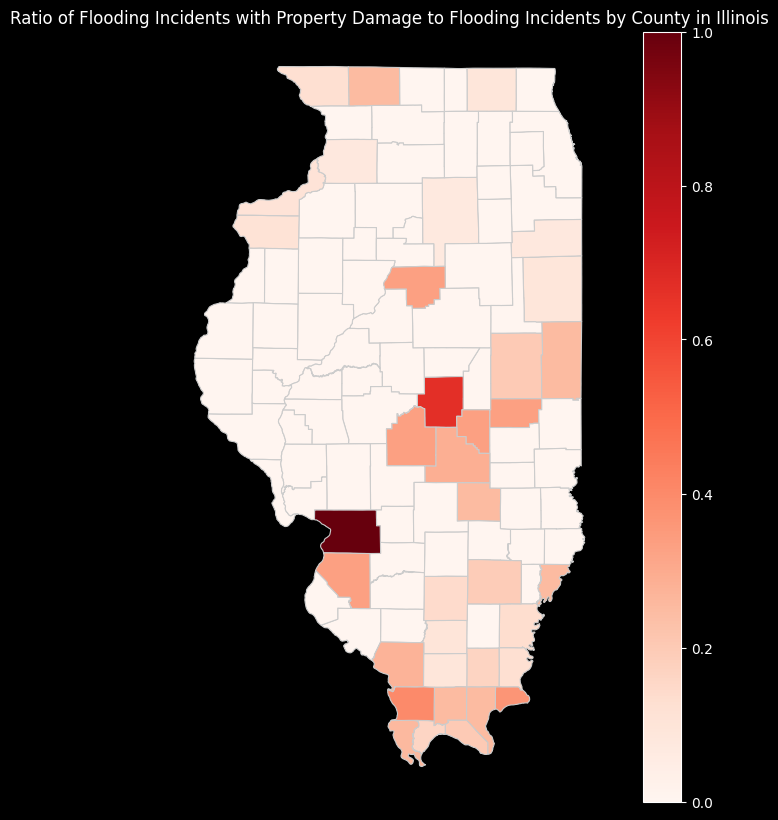

In [ ]:
# Count incidents with property damage > 0
flood_damage_counts = (
    merged_filled[
        (merged_filled['DAMAGE_PROPERTY'] > 0) &
        (
            (merged_filled["EVENT_TYPE"] == "Flood")
        )
    ]
    .groupby('county')
    .size()
    .reset_index(name="flood_damage_count")
)


flood_counts = (
    merged_filled[
        (
            (merged_filled["EVENT_TYPE"] == "Flood")
        )
    ]
    .groupby('county')
    .size()
    .reset_index(name="flood_count")
)
# Clean county names to match the shapefile
flood_counts['county'] = (
    flood_counts['county']
    .str.replace('-', ' ', regex=False)
    .str.replace('.', '', regex=False)
    .str.strip()
    .str.upper()
)

# Clean county names to match the shapefile
flood_damage_counts['county'] = (
    flood_damage_counts['county']
    .str.replace('-', ' ', regex=False)
    .str.replace('.', '', regex=False)
    .str.strip()
    .str.upper()
)
illinois_map['county'] = (
    illinois_map['COUNTY_NAM']
    .str.replace('-', ' ', regex=False)
    .str.replace("LASALLE", "LA SALLE", regex=False)
    .str.replace("DEKALB", "DE KALB", regex=False)
    .str.replace("DEWITT", "DE WITT", regex=False)
    .str.replace("DUPAGE", "DU PAGE", regex=False)
    .str.replace("ST. CLAIR", "ST ClAIR", regex=False)
    .str.strip()
    .str.upper()
)

map_data = illinois_map.merge(flood_damage_counts, on='county', how='left')
map_data = map_data.merge(flood_counts, on="county", how="left")

map_data['flood_damage_count'] = map_data['flood_damage_count'].fillna(0)
map_data["flood_count"] = map_data['flood_count'].fillna(0)

map_data['flood_damage_ratio'] = map_data.apply(
    lambda row: row['flood_damage_count'] / row['flood_count'] if row['flood_count'] > 0 else 0,
    axis=1
)

fig, ax = plt.subplots(1, 1, figsize=(10, 10))



map_data.plot(
    column='flood_damage_ratio',
    cmap='Reds',
    linewidth=0.8,
    ax=ax,
    edgecolor='0.8',
    legend=True
)

plt.title('Ratio of Flooding Incidents with Property Damage to Flooding Incidents by County in Illinois')
plt.axis('off')
plt.show()
pd.set_option('display.max_rows', None)
